# Draft

In [132]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.manifold import MDS, TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram

from src.repartition.data_loading import get_annotation, tif_to_real_mask
from src.repartition.data_analysis import *
from src.repartition.visualization import plot_distribution, plot_tumor_slide_grid, \
                                            export_furthest_tissue_pdf, export_mask_pdf, \
                                            export_tissues_proportion
from src.repartition.constants import PROJECT_ROOT, PATH_PATIENT_DATA

In [2]:
%load_ext autoreload
%autoreload 1
%aimport src.repartition.data_loading, src.repartition.data_analysis, src.repartition.visualization, src.repartition.constants

## Load paths

In [3]:
project_root = PROJECT_ROOT
annot_dir = project_root / 'data/repartition/annotation/'
annotations_paths = glob.glob(str(annot_dir) + "/" +'*.tif')
annotations_paths = np.array(annotations_paths)
slides_annot = get_annotation(annotations_paths, tif_to_real_mask)

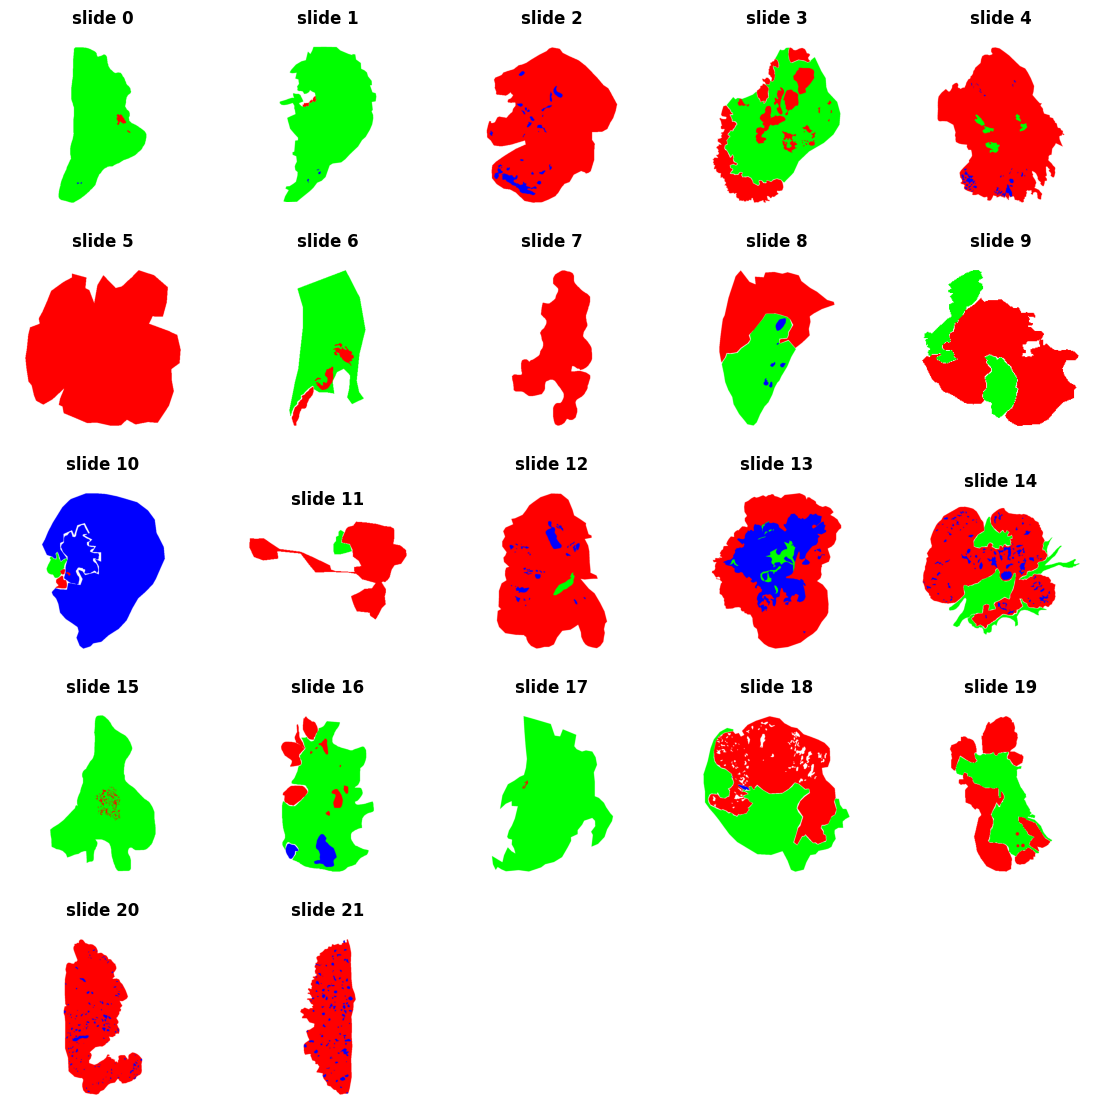

In [33]:
plot_tumor_slide_grid(slides_annot) 

In [4]:
distance_data, distribution_data = get_tissues_data(slides_annot, return_kde=True)
#distance_data.to_csv('tissues_info.csv')

In [7]:
export_mask_pdf(
    slides_annot,
    output="masks.pdf"
)

In [8]:
export_furthest_tissue_pdf(
    slides_annot, 
    distance_data, 
    tissue_type='tumor',
    output="furthest_tumors.pdf",
    saveimg=False
)

In [ ]:
all_tissue_areas = get_areas(distance_data)
export_tissues_proportion(
    all_tissue_areas, 
    draw_type='bar',
    saveimg=False
)

In [ ]:
furthest_tum = get_furthest_tumors(distance_data, by='id-slide')
furthest_tum.to_csv('furthest_tumors.csv')

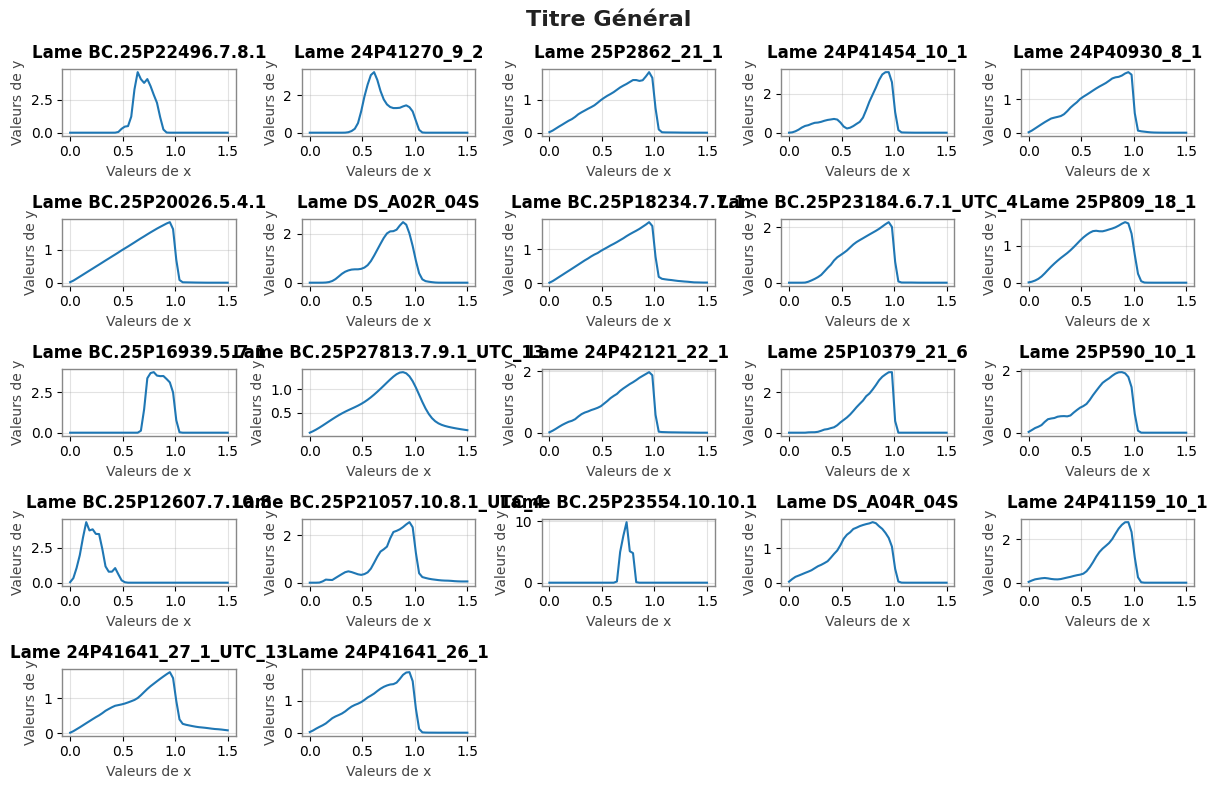

In [9]:
plot_distribution(distribution_data, show='kde', ref='center')

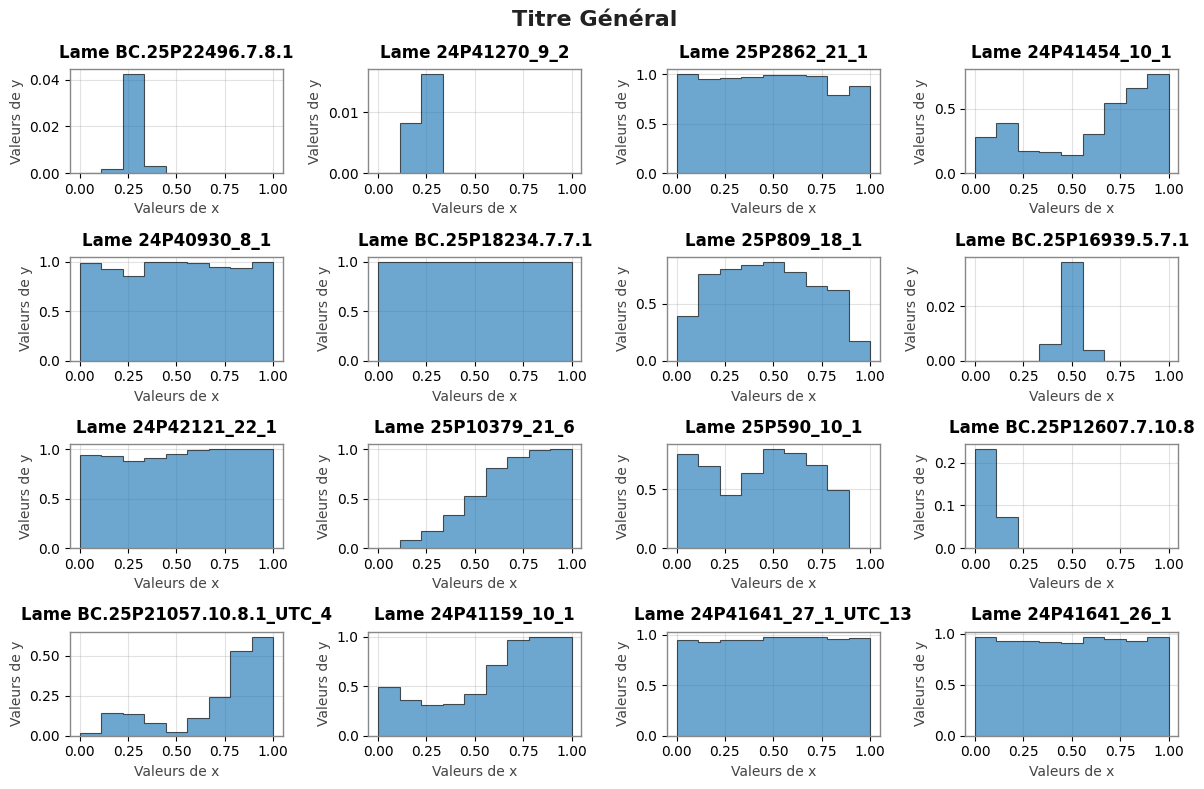

In [34]:
plot_distribution(distribution_data, show='hist-type-proportion')

In [72]:
eval_points = np.linspace(0, 1, 50)
bins = np.linspace(0, 1, 20)
# [0.6, 0, 0.4] ou [0.5, 0, 0.5]
weights = [0.5, 0.0, 0.5]
kde_vec, hist_vec, other_feats = extract_features(distribution_data, eval_points, bins, distance_data=distance_data, slides_annot=slides_annot, only_distrib=False)
dist_matrix = compute_distance_matrix(kde_vec, hist_vec, weights, eval_points, bins, additional_feats=other_feats)

In [ ]:
clustering = AgglomerativeClustering(
    n_clusters=5,
    metric='precomputed',
    linkage='average'           # 'ward' incompatible avec precomputed
)
labels_agglo = clustering.fit_predict(dist_matrix)

clustering = DBSCAN(eps=0.1, min_samples=1, metric='precomputed')
labels_dbscan = clustering.fit_predict(dist_matrix)


mds = MDS(n_components=2, metric='precomputed', random_state=42, n_init=1, init='classical_mds')
X_mds = mds.fit_transform(dist_matrix)

tsne = TSNE(n_components=2, metric='precomputed', random_state=42, perplexity=5, init=X_mds)
X_tsne = tsne.fit_transform(dist_matrix)


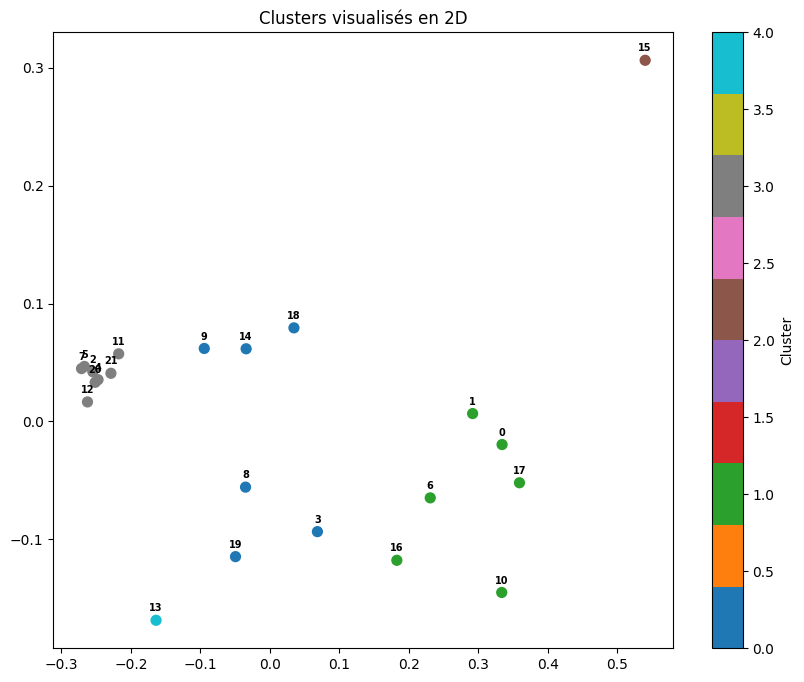

In [84]:
X = X_mds
labels = labels_agglo

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=50)
plt.colorbar(scatter, label='Cluster')

for i, (x, y) in enumerate(X):
    ax.annotate(str(i), (x, y), fontsize=7, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

plt.title('Clusters visualisés en 2D')
plt.show()

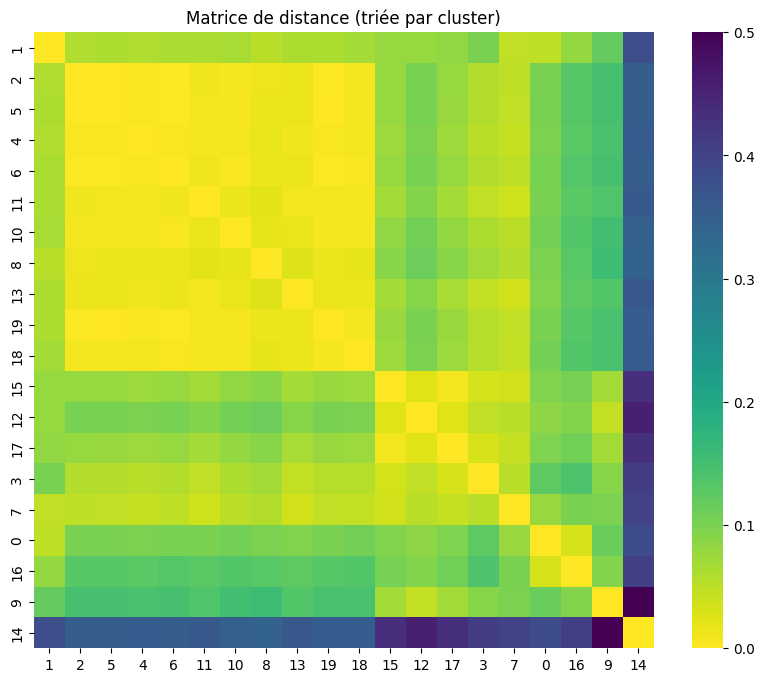

In [77]:
order = np.argsort(labels_agglo)
plt.figure(figsize=(10, 8))
sns.heatmap(
    dist_matrix[order][:, order],
    cmap='viridis_r',
    xticklabels=order,
    yticklabels=order
)
plt.title('Matrice de distance (triée par cluster)')
plt.show()

# Processing patient data

In [5]:
data = pd.read_excel(PATH_PATIENT_DATA)

In [6]:
cols_to_drop = ['En attente', 'Anonymisation', 'Sexe', 'Annee de naissance',
                'Annee du sevrage', 'Année de diagnostic',
                'PA', 'Année de diagnostic', 'Age au diagnostic', 'Methode diagnostic',
                'Taille tumorale après TTT (en mm)', 'Taille du lit tumoral (en mm)']

data.drop(columns=cols_to_drop, inplace=True)

In [7]:
cols_to_select = [
    'Patient',
    'Type histologique', 'Stade clinique',
    'Type de chirurgie', 'Regression pathologique'
]

data_light = data[cols_to_select]
data_light.dropna(inplace=True)
data_light['Patient'] = data_light['Patient'].str.strip()

In [8]:
tumors = get_furthest_tumors(distance_data, by='id-slide')

In [46]:
tumors = tumors.merge(data_light, how='inner', left_on='id-patient', right_on='Patient')

/tmp/ipykernel_6766/3129627694.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=tumors['Patient'], rotation=90);


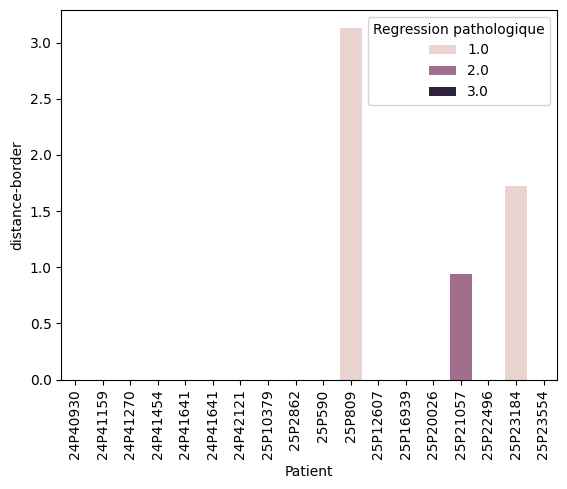

In [65]:
ax = sns.barplot(tumors, x='Patient', y='distance-border', hue='Regression pathologique')
ax.set_xticklabels(labels=tumors['Patient'], rotation=90);

In [8]:
def get_label_patient(label, distribution_data, data_light):
    df_light = {row['Patient'].strip(): row.drop('Patient').to_dict() for i, row in data_light.iterrows()}
    labels = [df_light[id_patient(sld_name)][label] for sld_name in distribution_data 
              if id_patient(sld_name) in df_light]
    return labels

In [49]:
distribution_data_filtered = {k: v for k, v in distribution_data.items() if id_patient(k) in data_light['Patient'].values}

In [148]:
eval_points = np.linspace(0, 1, 50)
bins = np.linspace(0, 1, 20)
# [0.6, 0, 0.4] ou [0.5, 0, 0.5]
weights = [0.5, 0.0, 0.5]
kde_vec, hist_vec, other_feats = extract_features(
    distribution_data, eval_points, 
    bins, distance_data=distance_data, 
    slides_annot=slides_annot, only_distrib=False
)
dist_matrix = compute_distance_matrix(kde_vec, hist_vec, weights, eval_points, bins, additional_feats=other_feats)

In [149]:
# LABELS
agglo_clustering = AgglomerativeClustering(
    n_clusters=6,
    metric='precomputed',
    linkage='average',           # 'ward' incompatible avec precomputed
    compute_distances=True,
)
labels_agglo = agglo_clustering.fit_predict(dist_matrix)

clustering = DBSCAN(eps=0.1, min_samples=1, metric='precomputed')
labels_dbscan = clustering.fit_predict(dist_matrix)

labels_patient = get_label_patient(
    'Regression pathologique', 
    distribution_data_filtered,
    data_light
)

# PROJECTION 2D
mds = MDS(n_components=2, metric='precomputed', random_state=42, n_init=1, init='classical_mds')
X_mds = mds.fit_transform(dist_matrix)

tsne = TSNE(n_components=2, metric='precomputed', random_state=42, perplexity=8, init=X_mds)
X_tsne = tsne.fit_transform(dist_matrix)


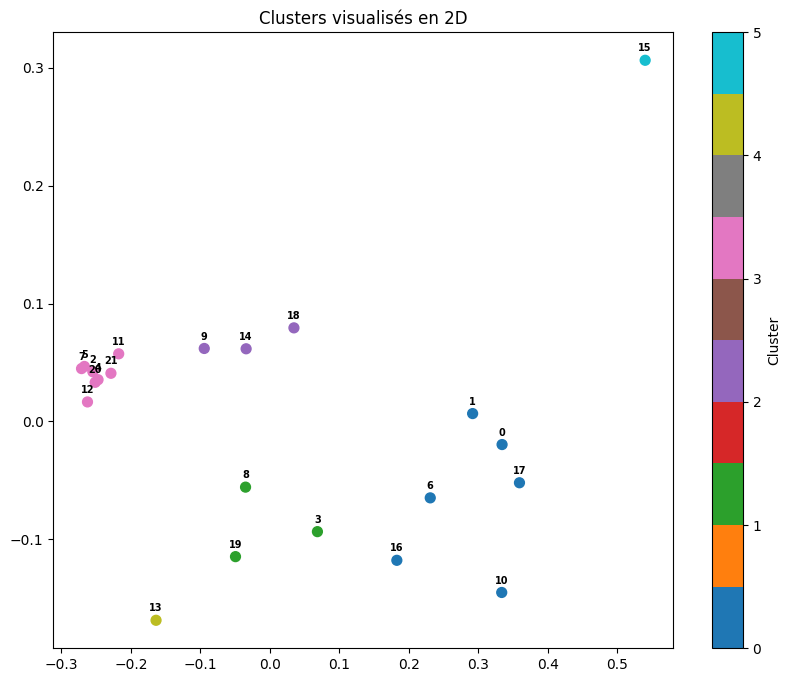

In [150]:
X = X_mds
labels = labels_agglo

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=50)
plt.colorbar(scatter, label='Cluster')

sld_list = list(distribution_data_filtered.keys())

for i, (x, y) in enumerate(X):
    ax.annotate(str(i), (x, y), fontsize=7, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

plt.title('Clusters visualisés en 2D')
plt.show()

In [154]:
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import squareform

Text(0.5, 1.0, 'Shepard plot — idéalement tous les points sur la diagonale')

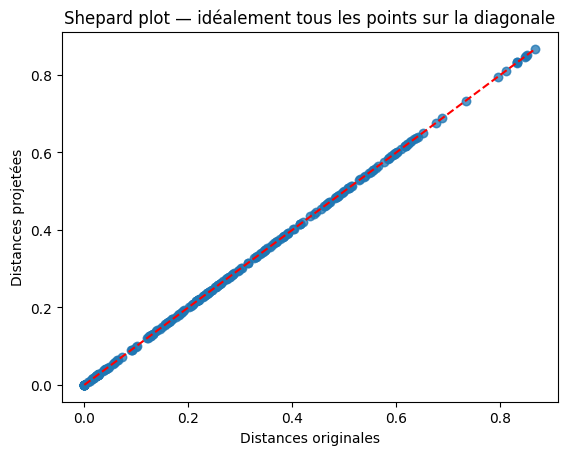

In [168]:
dist_2d = pairwise_distances(X)

orig = dist_matrix
proj = mds.dissimilarity_matrix_

plt.scatter(orig, proj, alpha=0.5)
plt.plot([orig.min(), orig.max()], [orig.min(), orig.max()], 'r--')
plt.xlabel("Distances originales")
plt.ylabel("Distances projetées")
plt.title("Shepard plot — idéalement tous les points sur la diagonale")

In [146]:
score = silhouette_score(dist_matrix, labels, metric='precomputed')
print(f"Silhouette : {score:.3f}")  # Entre -1 et 1, > 0.5 = bons clusters

Silhouette : 0.546


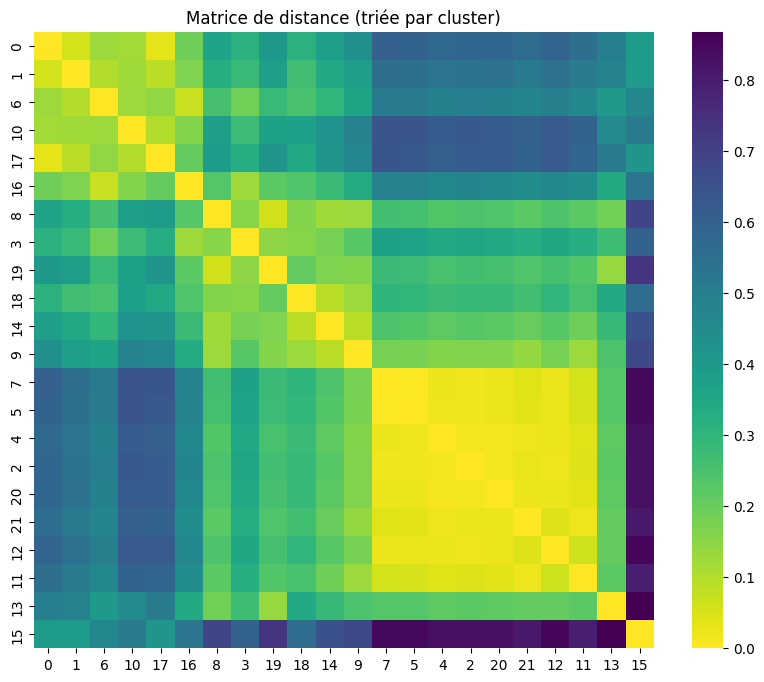

In [151]:
order = np.argsort(labels_agglo)
plt.figure(figsize=(10, 8))
sns.heatmap(
    dist_matrix[order][:, order],
    cmap='viridis_r',
    xticklabels=order,
    yticklabels=order
)
plt.title('Matrice de distance (triée par cluster)')
plt.show()

In [ ]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

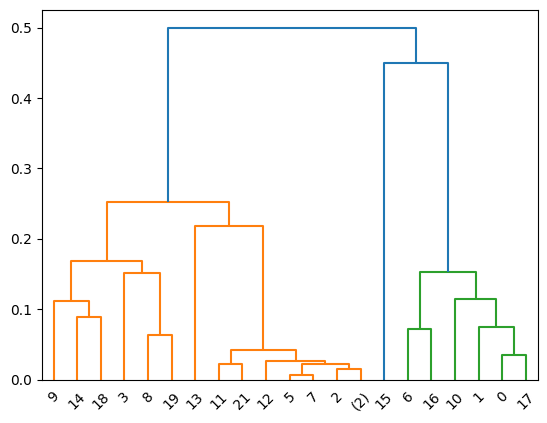

In [131]:
plot_dendrogram(agglo_clustering, truncate_mode="level", p=6)

In [98]:
mds.stress_

np.float64(9.028703381253438e-29)